# 0.  Introduction to PlatoSim

Example script how to use the `SimFile` and Simulation classes

## Setup notebook

In [2]:
#!/usr/bin/env Python3

# Alow changes to the PlatoSim code 
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using matplotlib backend: <object object at 0x7f739998f5d0>


## Imports

In [48]:
import os
import yaml
from yaml.loader import SafeLoader
import pyaml
import h5py
import numpy as np
from matplotlib import pyplot as plt
from astropy.io import fits

# import platosim.plot as plot
from platosim.simulation import Simulation
from platosim.simfile    import SimFile

# Plot Latex font
plt.rc('text', usetex=True)

## Setup and run a simulation

First we define the I/O paths and files needed for PlatoSim.

In [25]:
# We use the default input YAML file and configure is later
inputDir  = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles"
inputFile = inputDir + "/inputfile.yaml"

# Save all output to current working directory
outputDir      = os.getcwd()
outputFileName = "output_example1"

Now a simulation object can be created. Note that by default PlatoSim used the YAML input file located at `PLATO_PROJECT_HOME`, however, we here show how to include it directly in the simulation construction. 

In [26]:
# Set up a Simulation object
sim = Simulation(outputFileName, inputFile, outputDir=outputDir)

Note that you can set the output directory afterwards as well
`sim.outputDir = outputDir`. However, choose one since setting both will make PlaotSim complain.

For now we use the default YAML settings to run our simulation. Note that by default PlatoSim do not overwrite the output from a previous simulation defined by the same name. To avoid that PlatoSim ends in errors, we here activate the `removeOutputFile` option: 

In [27]:
# Run PlatoSim
simFile = sim.run(removeOutputFile=True)

Congratulations, you have a now generated your first PlatoSim simulation with Python!

## Configuring the YAML input file

Now say that we want to configure the input parameters but we don't want to open up the YAML input file to do so (e.g. because we want to make an automated script for our simulations). Again first we create an simulation object:

In [74]:
# Initialise PlatoSim
sim = Simulation("output_example2", outputDir=outputDir)

Since we are persistent and really don't want to open the YAML file manually, let's have a look at it's content from within Python. Here we use the `SafeLoader` option of the `yaml` package, while we print (or dump) the data more nicely with the `pyaml` package: 

In [75]:
# Open and print content
with open(inputFile) as f:
    data = yaml.load(f, Loader=SafeLoader)
    print(pyaml.dump(data))

CCD:
  BFE:
    CoefficientsFileName: inputfiles/a_bfe.hdf5
  CTI:
    Model: Short2013
    Short2013:
      Beta: 0.37
      NumTrapSpecies: 4
      ReleaseTime:
        - 0.000237
        - 0.0243
        - 0.00203
        - 0.14
      Temperature: 203.0
      TrapCaptureCrossSection:
        - 2.46e-20
        - 1.74e-22
        - 7.05e-23
        - 2.45e-23
      TrapDensity:
        BOL:
          - 0.0
          - 0.0
          - 0.0
          - 0.0
        EOL:
          - 9.8
          - 3.31
          - 1.56
          - 13.24
    Short2013FromFile:
      CTIFileName: inputfiles/ctiInput.hdf5
    Simple:
      MeanCTE: 0.99999
  ChargeInjection:
    FirstRow: 50
    InjectionLevel: 90.0
    RowInterval: 100
  Contamination:
    MolecularContaminationEfficiency: 0.9573
    ParticulateContaminationEfficiency: 0.972
  DarkSignal:
    DSNU: 15.0
    DarkCurrent: 1.2
    Stability: 5.0
  DigitalSaturation: 65535
  FirstRowExposed: 0
  FlatfieldNoiseRMS: 0.01
  FullWellSaturation: 90

Note that `pyaml` outputs everything alphabetically, however, the real YAML input file has a different structure (so don't panic). After an overview of the input parameters let's assume we want to change the following parameters:

In [76]:
# Observation
sim["ObservingParameters/NumExposures"] = 1

# Sky
sim["Sky/SkyBackground"]         = -1
sim["Sky/Cosmics/CosmicHitRate"] = 1

# Subfield
sim["SubField/NumColumns"]      = 300
sim["SubField/NumRows"]         = 300
sim["SubField/ZeroPointColumn"] = 0
sim["SubField/ZeroPointRow"]    = 0

# CCD
sim["CCD/IncludeCTIeffects"]  = False
sim["CCD/Gain/RefValueLeft"]  = 2.14 
sim["CCD/Gain/RefValueRight"] = 2.14 

# Control HDF5
sim["ControlHDF5Content/WriteStarPositions"] = True

We have chosen to simulate only 1 image, set the sky background to be estimated from an automatic tabulation according to the sky location (done with the `-1`), and we reduced the cosmic ray hit rate to "quiet" space weather conditions for PLATO (according to the results of the PLATO working group). The subfield is enlarged but we keep the simulation in the origo-corner of the CCD. We have likewise diabled the effect of Charge Transfer Inefficiency (CTI) and secured a identical CCD gain for the E and F side of each of the 4 CCDs in the camera focal plane. Let's run the simulation:

In [78]:
# Run PlatoSim
simfile = sim.run(removeOutputFile=True)

## Fetching the HDF5 output file

To access the HDF5 output file that contains your simulated data, we can simply use the `SimFile` class:

In [80]:
# Fetch HDF5 output
f = SimFile(outputFileName + ".hdf5")

## Plot the simulated subfield

Plotting your simulated pixel images can be done out-of-box using the `showImage` utility of the `SimFile` class. To plot say the first image simply use:

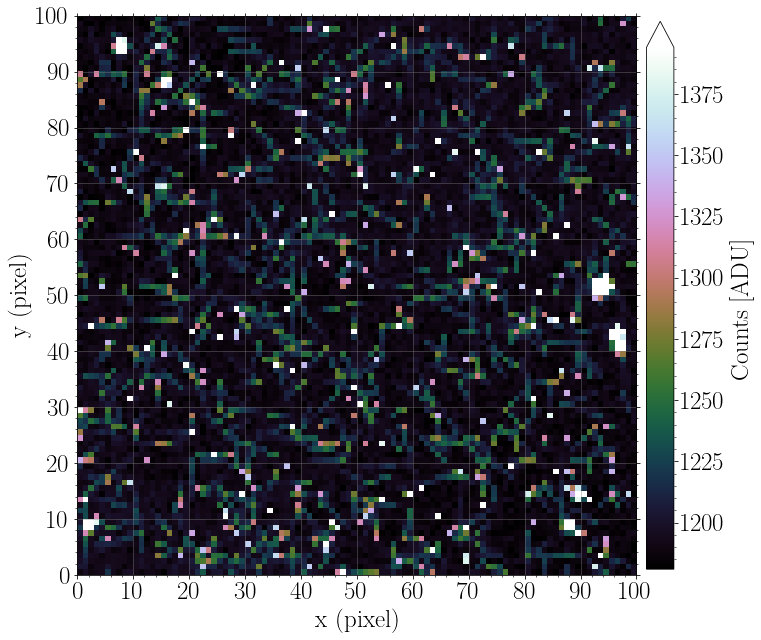

In [81]:
imageNr = 0
fig = f.showImage(imageNr, clipPercentile=1, imgScale="clip",  
                  figsize=(12,12), fontSize=25, useTitle=False,
                  showStarPositions=False, showStarIDs=False,
                  colorMap="cubehelix", colorBar=True, showGrid=True) 


Note that a Matplotlib figure object is returned allowing you to change the plot before e.g. saving it to file.

In [2]:
# Specify the absolute paths of some of the input files and the output folder.
# The following default values will always work, but we advice you not to use
# them, but make your own input and output folders (and specify their paths here),
# so that you don't pollute the PlatoSim base inputfiles/ or python/ folders.

inputDir    = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles"
inputFile   = inputDir + "/inputfile.yaml"
starCatalog = inputDir + "/guide_stars_EQ.txt"
jitterFile  = inputDir + "/PlatoJitter_Airbus.txt"
psfFile     = inputDir + "/psf.hdf5"

outputDir   = os.getcwd()
outputFilePrefix = "/FGS_"

In [ ]:
# Read the guide star catalog

ra, dec, V, starID = np.loadtxt(starCatalog, unpack=True)
NguideStars = len(ra)

# For each guide star, center a subfield around it, and run the simulator

for n in range(NguideStars):

    print("Running the simulator for guide star {0}".format(starID[n]))
    print("Guide Star Coordinates [deg]: {}, {}".format(ra[n], dec[n]))

    # Set up a Simulation object

    sim = Simulation(outputFilePrefix + "{0:04d}".format(n), inputFile)
    sim.outputDir = outputDir

    # Set the simulation parameters

    sim["ObservingParameters/StarCatalogFile"] = starCatalog
    sim["Platform/JitterSource"] = "FromFile"
    sim["Platform/JitterFileName"] = jitterFile
    sim["PSF/MappedFromFileSymmetrical/Filename"] = psfFile 
    sim["ObservingParameters/RApointing"] = 86.79870
    sim["ObservingParameters/DecPointing"] = -46.39595
    sim["ObservingParameters/CycleTime"] = 2.5 
    sim["Camera/IncludeFieldDistortion"] = False
    sim["Telescope/GroupID"] = "Fast"

    # Center the subfield around the current guide star
    # First extract the required information from the yaml input file.
    # Note that for this simulation, we want to use the fast cams, not the nominal ones.
    #
    # This function sets the following configuration parameters:
    # 
    # CCD/OriginOffsetX
    # CCD/OriginOffsetY
    # CCD/Orientation
    # CCD/NumColumns
    # CCD/NumRows
    # 
    # SubField/ZeroPointRow
    # SubField/ZeroPointColumn
    # SubField/NumRows
    # SubField/NumColumns
    # 
    # ObservingParameters/CycleTime
    # 

    subfieldSizeX = 9     # column width [pixels]
    subfieldSizeY = 9     # row width [pixels]
    normalCamera = False  # fast camera

    hasCcdCode = sim.setSubfieldAroundCoordinates(np.deg2rad(ra[n]), np.deg2rad(dec[n]), 
                                                  subfieldSizeX, subfieldSizeY, normalCamera)

    # If the star does not fall on a CCD, or is too close to the edge, skip it.

    if not hasCcdCode:
        continue

 
    # Make sure that the random seeds are set different for each guide star,
    # so that they have all different noise realisations.

    sim["RandomSeeds/PhotonNoiseSeed"]  = 1433237514 + n
    sim["RandomSeeds/ReadOutNoiseSeed"] = 1424949740 + n
    sim["RandomSeeds/FlatFieldSeed"]    = 1425284070 + n
    sim["RandomSeeds/JitterSeed"]       = 1424967476 + n
    sim["RandomSeeds/DriftSeed"]        = 1433826961 + n


    # Run the simulation without the flux extraction, with an HDF5 file as output

    simFile = sim.run()